# Trans-C sampling of a multi-modal posterior distribution

This example demonstrates the use of the state-jump Trans-C sampling algorithm on a posterior PDF consisting of a multi-modal Gaussian Mixture model.

### Problem setup

The unknowns represent a 1D layered Earth model of log conductivities. This is typical in an Airborne EM inversion problems, from which this example is derived.

<div style="text-align: center;">
<img src="../AirborneEM/AEM_data/Layer_param.png" alt="1D variable layer parameterization" width="250"/>
</div>

10 independent states are used such that state $k$, ($k=0,\dots,9$) has $k$ variable depth layers and $k$ log-conductivities over a halfspace whose conductivity is also allowed to vary, making $2k+1$ unknowns.

#### A test problem with a multi-modal posterior PDF and known relative evidence values across the states

This notebook constructs a synthetic test sampling problem for Trans-C algorithms. A multi-modal posterior distribution is built consisting of a Gaussian Mixture Model (GMM). This is done by fitting the GMM to an ensemble of posterior samples in each state calculated from the AEM example. The GMM then serves a test case of multi-modal **normalized posterior** distribution from which any desired relative evidence values can be imposed to produce an **unormalized posterior** for subseuqent Trans-C sampling. Since then we know what the true relative evidence values are, this serves as a test bed for comparing pseudo-prior construction, or other factors. The building of the posterior PDF is performed in routine `create_norm_log_posterior` which returns a class `log_posterior` for use here.

In [1]:
# standard libraries
import time
from functools import partial
import corner

import matplotlib.pyplot as plt
import numpy as np
import math
from IPython.display import display
from PIL import Image
from tqdm import tqdm
from utils.IO_utils import (
    create_InferenceData_object,
    read_ensembles,
    setproposalweights,
)
from utils.plot_utils import plot_ensembles, plot_histogram_is, generate_and_plot_samples

In [2]:
import scipy.stats as stats
from scipy.optimize import minimize
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor

#### TransC class

In [3]:
from pytransc.analysis.samples import resample_ensembles
from pytransc.analysis.visits import (
    count_state_changes,
    count_total_state_changes,
    get_acceptance_rate_between_states,
    get_autocorr_between_state_jumps,
    get_relative_marginal_likelihoods,
    get_visits_to_states,
)
from pytransc.samplers import run_state_jump_sampler, run_mcmc_per_state
from pytransc.pseudoprior import build_auto_pseudo_prior

#### Utilities

In [4]:
# Import the functions to create log_posterior and log_proposal distributions for this problem
from density_functions import (
    create_log_posterior,
    create_log_diag_proposal
)

#### Create log posterior function

Now we choose a set of weights for each state and build a class to evaluate an unnormalized posterior PDF for each state from GMMs, with a function to draw samples from it. 

Calling sequence:

`log_posterior(x,state)` : evaluates (normalized) log posterior density for model `x` in state `state`.
    
`log_posterior.draw_deviate(state)`: draws an independent random deviate from posterior in state `state`.

This becomes useful test density function for sampling with Trans-C algorithms.

In [5]:
weights = [1,1,2,2,3,3,5,5,2,2] # Our choice of posterior relatve evidence values between states
Ev = weights/np.sum(weights)    # Normalized relative evidence between states
log_posterior,ndims = create_log_posterior("../AirborneEM/AEM_data",3,weights) #create unormalized posterior class of 3 components using weights
nstates = len(ndims)
print("Number of states: ", nstates)
print("Number of parameters in each state", ndims)
#print("Relative posterior evidence of states\n", Ev)

Number of states:  10
Number of parameters in each state [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]


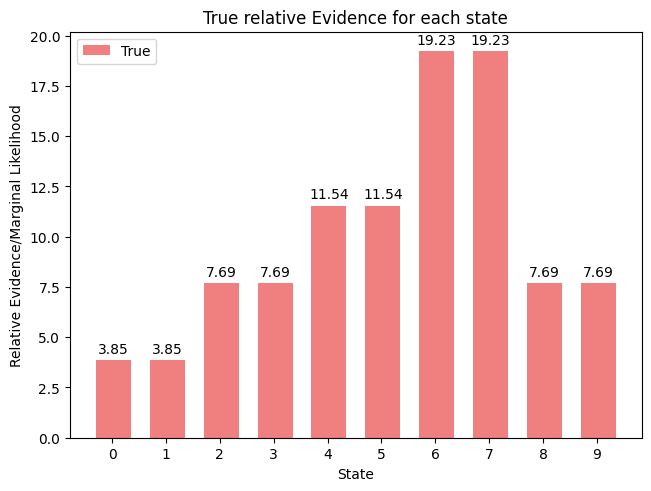

In [6]:
# plot True Evidence
labels = [str(i) for i in range(nstates)]
x = np.arange(nstates)  # the label locations
width = 0.65  # the width of the bars
Evpc = Ev*100
# plot
fig, ax = plt.subplots(layout="constrained")
multiplier = 1
offset = width * multiplier -0.3
rects = ax.bar(
        x + offset, np.round(Evpc, 2), width, label="True", color="lightcoral"
    )
ax.bar_label(rects, padding=3)
multiplier += 1
ax.set_ylabel("Relative Evidence/Marginal Likelihood")
ax.set_xlabel("State")
ax.set_title("True relative Evidence for each state")
ax.set_xticks(x + width / 2, labels)
ax.legend(loc="upper left")
plt.show()

#### Calculate starting points for Trans-C MCMC chains in each state via optimization

In [7]:
# generate samples from each state and get location with highest log posterior
ns,initial = 10000,[]
for state in range(nstates):
    s, lp = np.zeros((ns, ndims[state])), np.zeros(ns)
    for i in range(ns):
        x = log_posterior.draw_deviate(state)
        s[i, :] = x
        lp[i] = log_posterior(x,state)
    j = np.argmax(lp)
    initial.append(s[j])

In [8]:
# find good starting point for all McMC samplers in each state via optimization of log-posterior
rng = np.random.default_rng(42)
nsamples_es = nstates * [10000]  # number of samples per chain for sampling of each state
nwalkers_es = nstates * [64]     # number of mcmc chains to run in each state
nll = lambda *args: -log_posterior(*args)
pos,ml = [],[]
print("Maximum likelihood estimates:")
for i in range(nstates):
    start = initial[i]
    soln = minimize(nll, start, args=(i,))
    ml.append(soln.x)
    pos.append(soln.x + 1e-4 * rng.standard_normal((nwalkers_es[i], ndims[i])))
    #print("x_ml ", soln.x)

Maximum likelihood estimates:


#### Plot posterior with optimize locations

We take a quick look at the with a corner plot of samples, together with the MAP models
obtained from optimization. 

Here we plot the 5th ensemble which has 5 layers, with 4 interface depths and 5 conductivities. 

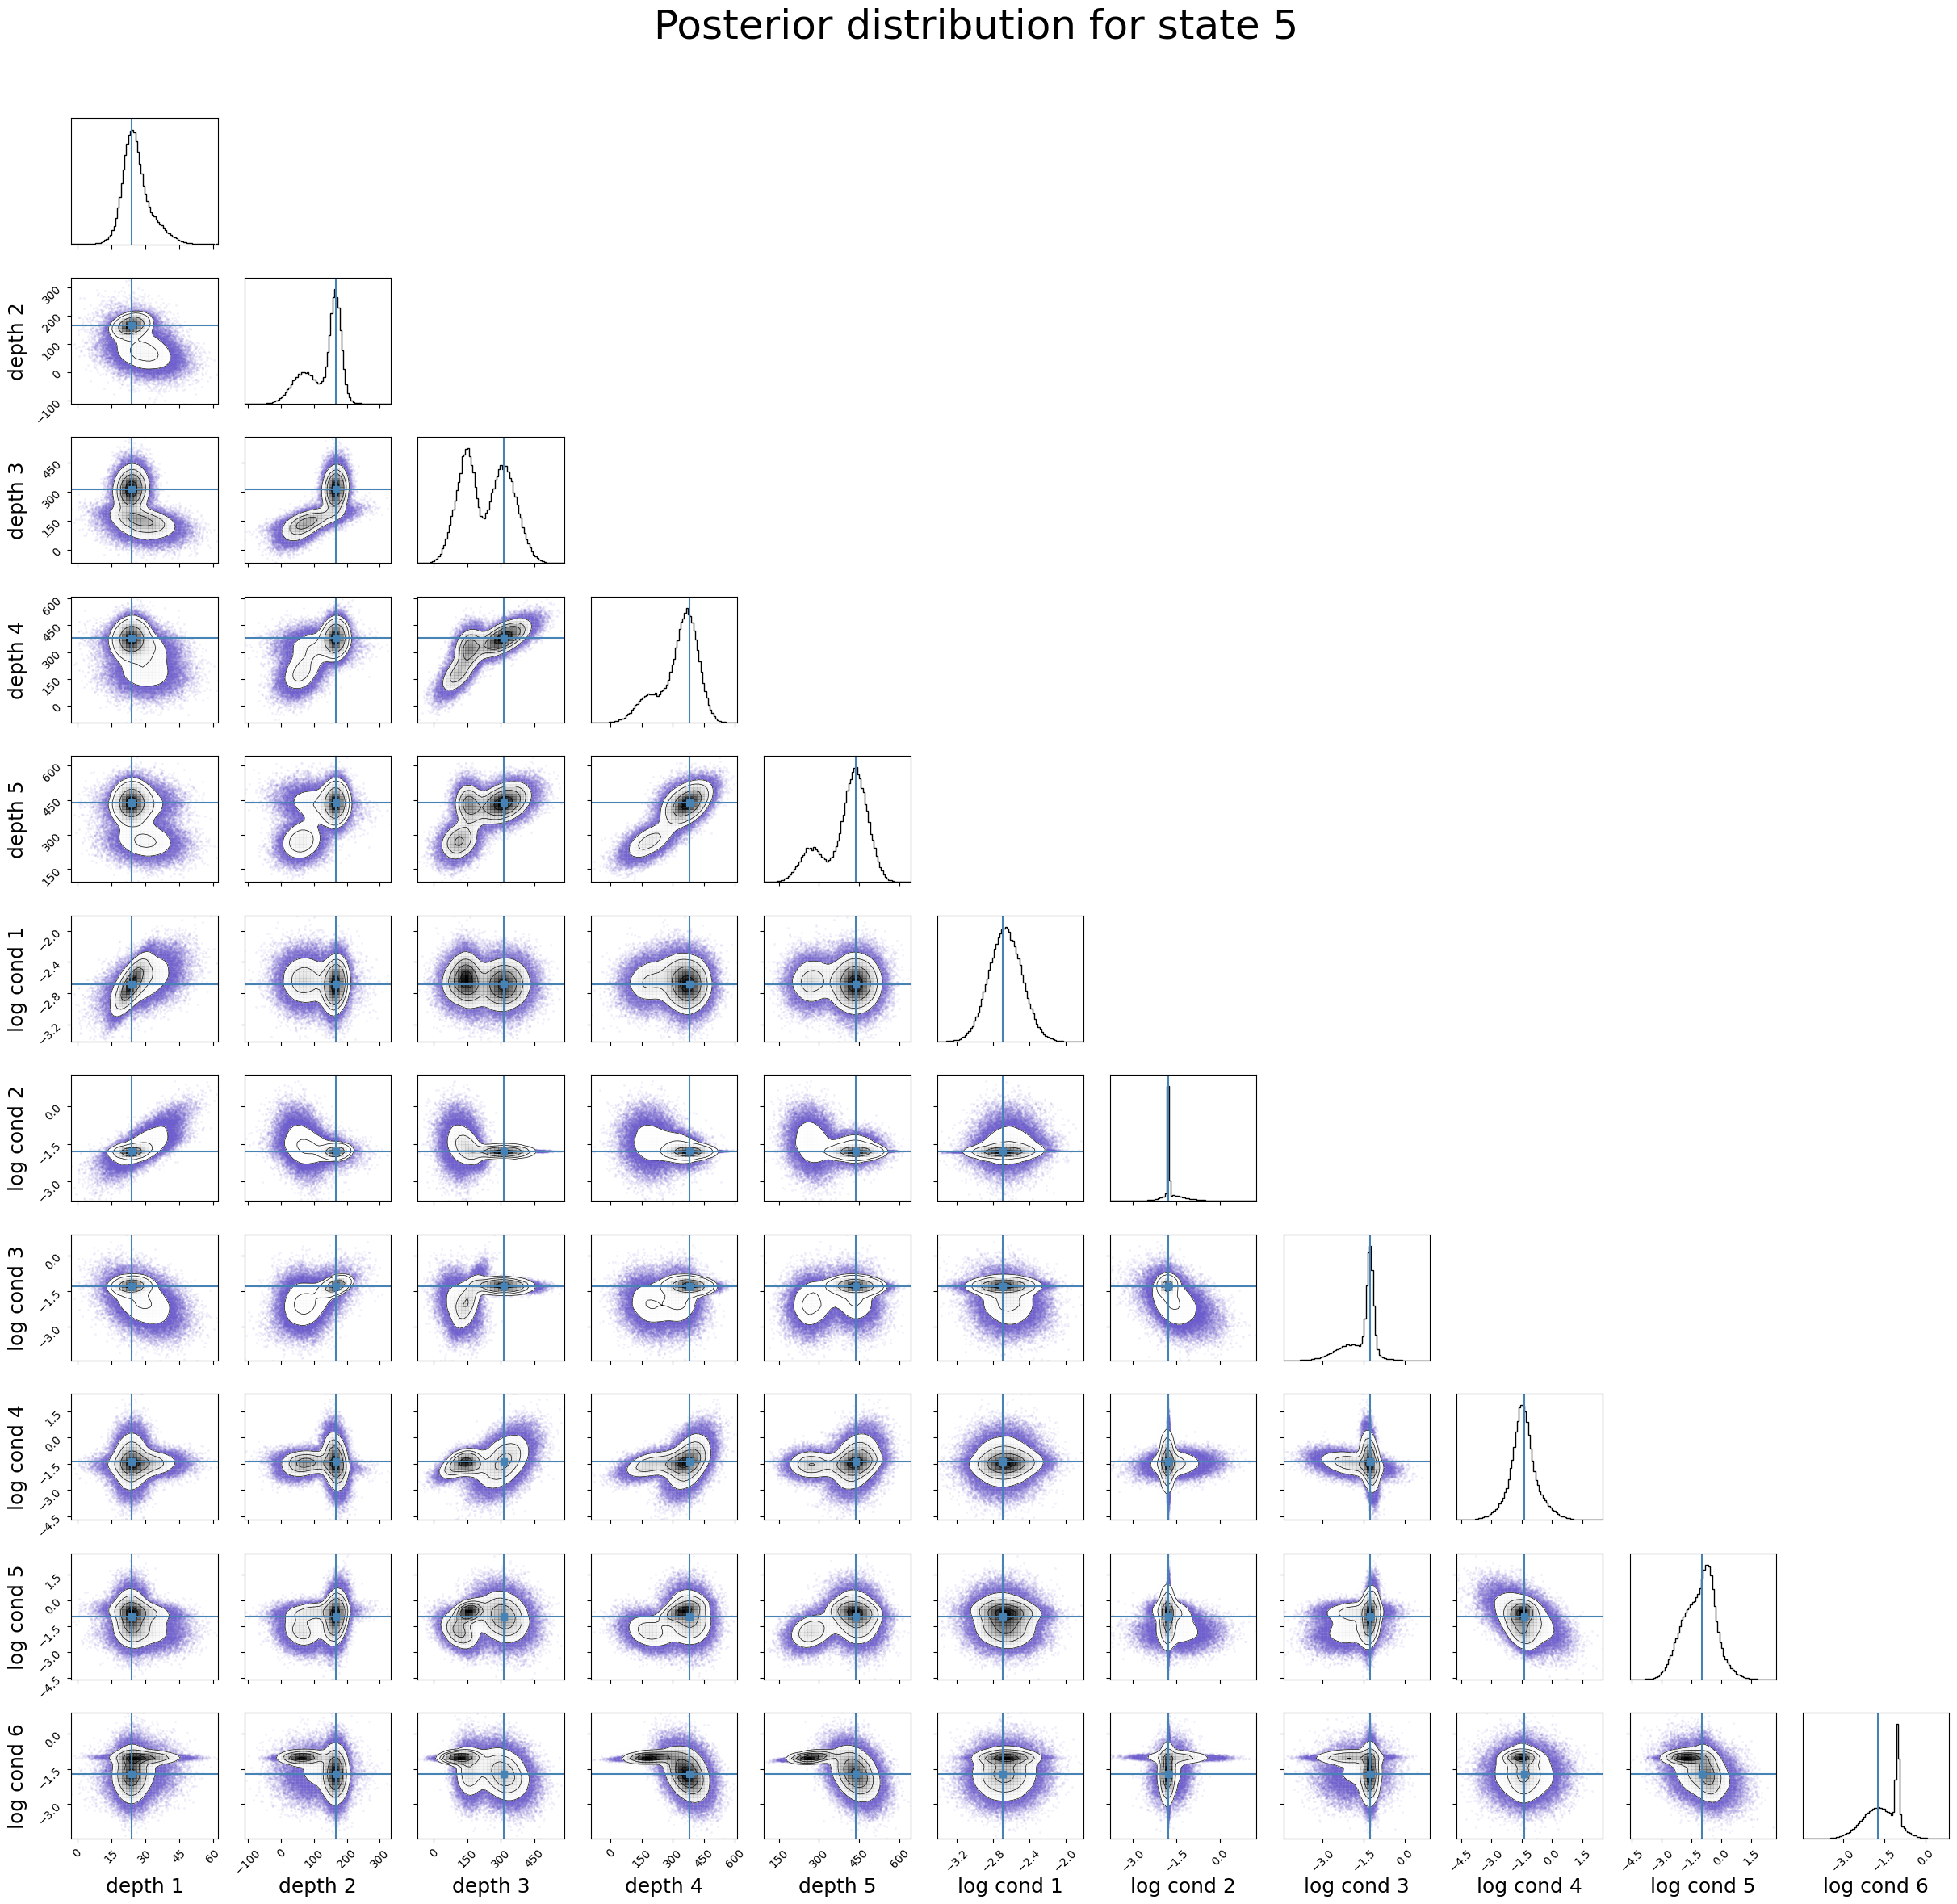

In [9]:
# generate and plots samples from posterior
state = 5
label_kwargs = {"fontsize": 18}
lp,s = generate_and_plot_samples(
    log_posterior,
    state,
    ndims,
    title='Posterior distribution for state '+str(state),
    titlefontsize=36,
    ns=100000,
    truths=ml[state],
    params=None,
    #filename="Posterior_samples_corner_" + str(state) + ".pdf",
    label_kwargs=label_kwargs,
) 

#### Calculate posterior ensembles in each state with MCMC

In [10]:
parallel = True
start_time = time.time()
if(parallel):
    n_state_procs = 5  # Number of processes used in state mode. Suggest set equal to number of states if possible.
    with ProcessPoolExecutor(max_workers=n_state_procs) as state_pool:
        ensemble_per_state, log_posterior_ens = run_mcmc_per_state(
            nstates,               # number of states
            ndims,                 # number of dimensions in each state
            nwalkers_es,           # number of walkers for each state
            nsamples_es,           # number of chain steps per walker
            pos,                   # starting positions for walkers in each state
            log_posterior,         # log posterior (likelihood x prior)
            discard=0,             # burnin number of chain steps to discard in eeach state
            auto_thin=True,        # thinning value, save every `thin` models
            state_pool=state_pool, # parallelization over states
            verbose=True)          # show progress bar for each state
else:
    ensemble_per_state, log_posterior_ens = run_mcmc_per_state(
        nstates,                   # number of states
        ndims,                     # number of dimensions in each state
        nwalkers_es,               # number of walkers for each state
        nsamples_es,               # number of chain steps per walker
        pos,                       # starting positions for walkers in each state
        log_posterior,             # log posterior (likelihood x prior)
        discard=0,                 # burnin number of chain steps to discard in eeach state
        auto_thin=True,            # thinning value, save every `thin` models
        verbose=True)              # show progress bar for each state    
elapsed_time = time.time() - start_time
print(f"Execution time: {elapsed_time:.2f} seconds")


Running within-state sampler separately on each state

Number of walkers               :  [64, 64, 64, 64, 64, 64, 64, 64, 64, 64]

Number of states being sampled:  10
Dimensions of each state:  [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
Using state-level parallelism


2025-12-19 20:24:48 [INFO] arviz.preview: arviz_base not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_base not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_base not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_base not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_base not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_stats not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_stats not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_stats not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_stats not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_stats not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_plots not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_plots not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_plots not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_plots not installed
2025-12-19 20:24:48 [INFO] arviz.preview: arviz_plots

Performing auto thinning of ensemble...
Execution time: 83.31 seconds


Times:

- Posterior sampling in each state Serial:  388 s
- Posterior sampling in each state Parallel: 84 s

#### Build a pseudo prior function from pre-computed posterior ensembles

In [11]:
log_pseudo_prior = build_auto_pseudo_prior(ensemble_per_state=ensemble_per_state,n_components=2, covariance_type='full',)

Now lets plot the pseudo prior.

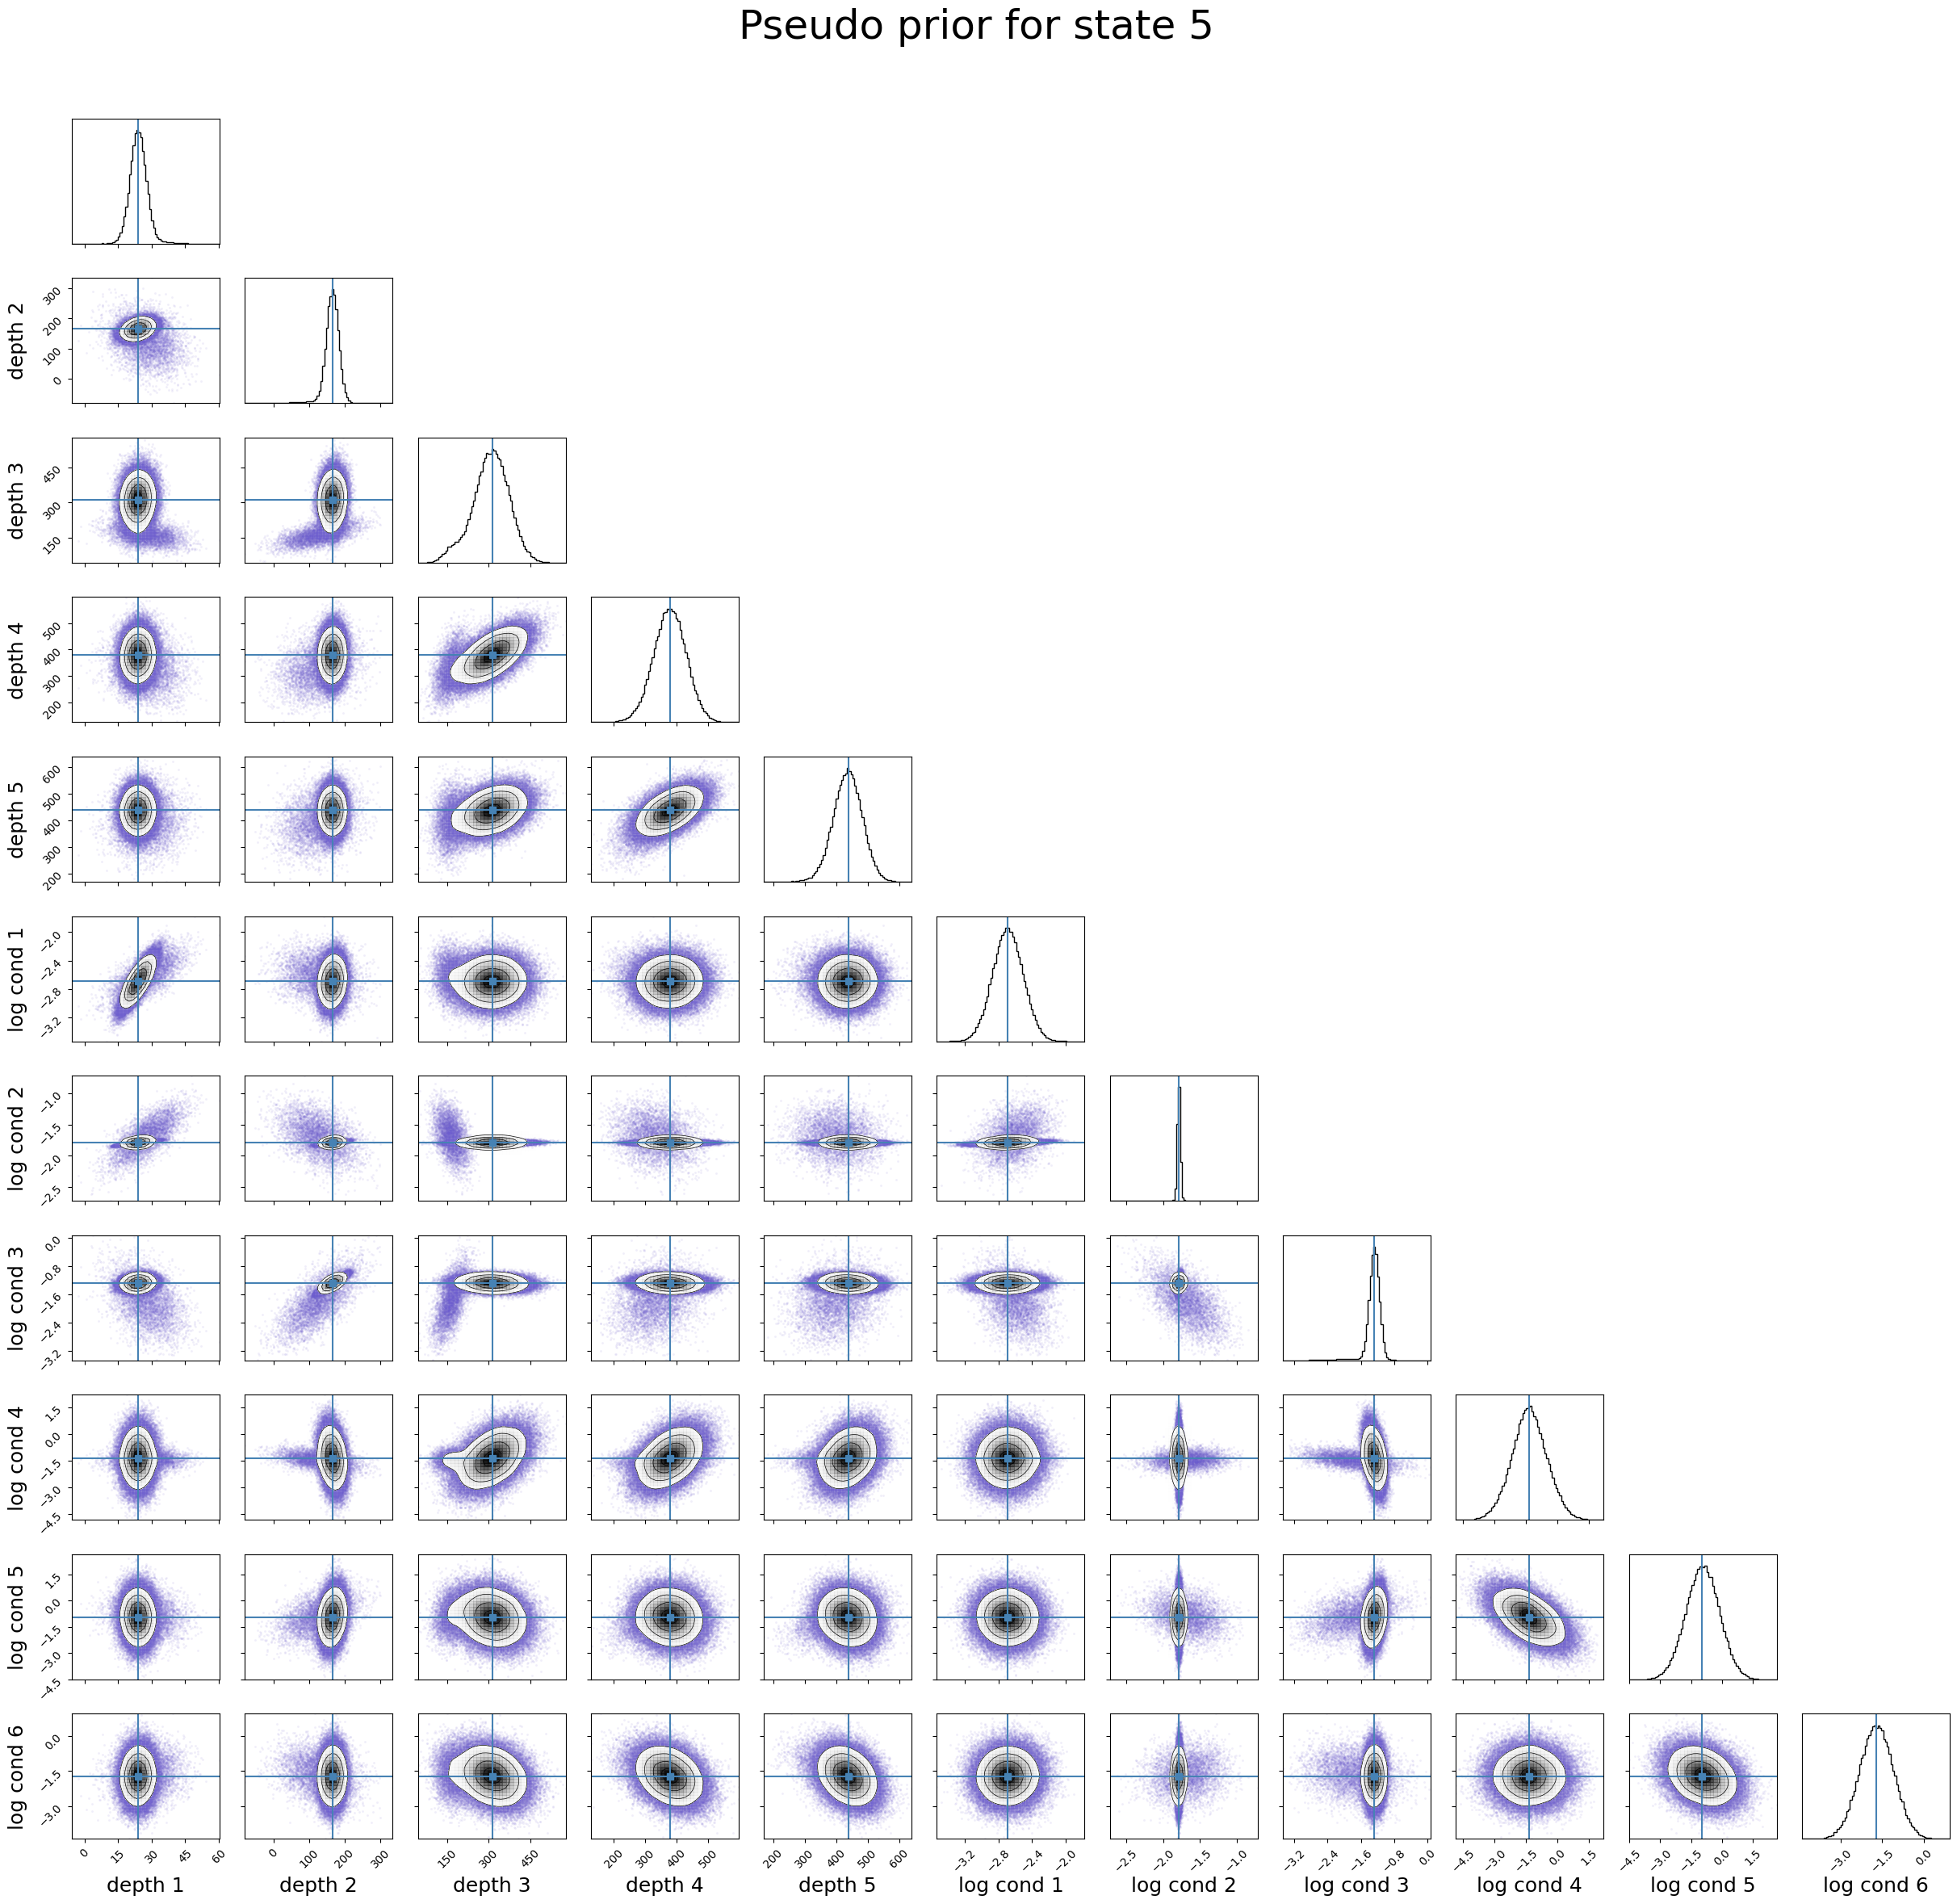

In [12]:
# generate and plots samples from posterior
state = 5
label_kwargs = {"fontsize": 18}
lp,s = generate_and_plot_samples(
    log_pseudo_prior,
    state,
    ndims,
    ns=100000,
    truths=ml[state],
    title='Pseudo prior for state '+str(state),
    titlefontsize=36,
    params=None,
    #filename="Pseudo_prior_samples_corner_" + str(state) + ".pdf",
    label_kwargs=label_kwargs,
) 

#### Build *a within-state* proposal

We create a diagonal Gaussian perturbation proposal centred on 0 using the variances given by the posterior ensembles calculated earlier.

In [13]:
log_proposal = create_log_diag_proposal(ensemble_per_state,1)

#### Starting points of state-jump MCMC chains

In [14]:
# starting points of state-jump MCMC chains
nwalkers_sj = 32    # Number of walkers
nsteps_sj = 100000  # Number of chain steps
pos_states = rng.choice(np.arange(nstates), nwalkers_sj)  # Initial states of each walker
pos = []
for i in range(nwalkers_sj):  # generate starting points for each walker
    pos.append(
        ml[pos_states[i]] + 1e-4 * rng.standard_normal(ndims[pos_states[i]])
    )  # add random perturbation to maximum Likelihood models

#### Run state-jump

In [15]:
start_time = time.time()
if(parallel):
    n_walker_procs = 5 # Number of processes used over walkers in state-jump sampling    
    print("\n=== Parallel execution of State-Jump sampler===")
    with ProcessPoolExecutor(max_workers=n_walker_procs) as walker_pool:
        state_jump_chains = run_state_jump_sampler(
            nwalkers_sj,              # number of state-jump walkers
            nsteps_sj,                # number of chain steps per walker
            nstates,                  # number of states
            ndims,                    # number of dimensions in each state
            pos,                      # starting positions for walkers
            pos_states,               # starting states for walkers
            log_posterior,            # log posterior (likelihood x prior)
            log_pseudo_prior,         # log pseudo-prior PDF for each state
            log_proposal,             # log proposal PDF for within state moves for each state
            progress=True,            # show progress bar
            walker_pool=walker_pool,  # Walker pool for parallelization of chains
        )
else:
    print("\n=== Serial execution of State-Jump sampler===")
    state_jump_chains = run_state_jump_sampler(
        nwalkers_sj,                  # number of state-jump walkers
        nsteps_sj,                    # number of chain steps per walker
        nstates,                      # number of states
        ndims,                        # number of dimensions in each state
        pos,                          # starting positions for walkers
        pos_states,                   # starting states for walkers
        log_posterior,                # log posterior (likelihood x prior)
        log_pseudo_prior,             # log pseudo-prior PDF for each state
        log_proposal,                 # log proposal PDF for within state moves for each state
        progress=True,                # show progress bar
    )
elapsed_time = time.time() - start_time
print(f"Execution time: {elapsed_time:.2f} seconds")

2025-12-19 20:26:30 [INFO] pytransc.samplers.state_jump: Running state-jump trans-C sampler
2025-12-19 20:26:30 [INFO] pytransc.samplers.state_jump: Number of walkers: 32
2025-12-19 20:26:30 [INFO] pytransc.samplers.state_jump: Number of states being sampled: 10
2025-12-19 20:26:30 [INFO] pytransc.samplers.state_jump: Dimensions of each state: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]



=== Parallel execution of State-Jump sampler===


  0%|                                                                                                                      | 0/32 [00:00<?, ?it/s]2025-12-19 20:26:31 [INFO] arviz.preview: arviz_base not installed
2025-12-19 20:26:31 [INFO] arviz.preview: arviz_stats not installed
2025-12-19 20:26:31 [INFO] arviz.preview: arviz_plots not installed
2025-12-19 20:26:31 [INFO] arviz.preview: arviz_base not installed
2025-12-19 20:26:31 [INFO] arviz.preview: arviz_base not installed
2025-12-19 20:26:31 [INFO] arviz.preview: arviz_stats not installed
2025-12-19 20:26:31 [INFO] arviz.preview: arviz_stats not installed
2025-12-19 20:26:31 [INFO] arviz.preview: arviz_base not installed
2025-12-19 20:26:31 [INFO] arviz.preview: arviz_plots not installed
2025-12-19 20:26:31 [INFO] arviz.preview: arviz_base not installed
2025-12-19 20:26:31 [INFO] arviz.preview: arviz_stats not installed
2025-12-19 20:26:31 [INFO] arviz.preview: arviz_plots not installed
2025-12-19 20:26:31 [INFO] arviz.preview: a

Execution time: 152.31 seconds


Times:

- State Jump sampler in serial mode:     650 s
- State Jump sampler in parallel mode:   153 s

#### Diagnostics

In [16]:
alg = "TransC-state-jump-sampler"
state_chain_tot = np.swapaxes(state_jump_chains.state_chain_tot, 0, 1)
state_chain = state_jump_chains.state_chain.T
model_chain = state_jump_chains.model_chain
accept_within_per_walker = (
    state_jump_chains.accept_within / state_jump_chains.prop_within
)
accept_between_per_walker = (
    state_jump_chains.accept_between / state_jump_chains.prop_between
)
accept_within = 100 * np.mean(accept_within_per_walker)
accept_between = 100 * np.mean(accept_between_per_walker)

In [17]:
# print some diagnostics
print("\n Algorithm type                                   :", alg)
# extract trans-D samples and chains
discard = 0  # chain burnin
thin = 15  # chain thinning
visits, states_chain = get_visits_to_states(
    transc_sampler=state_jump_chains,
    discard=discard,
    thin=thin,
    normalize=True,
)
visits = visits.swapaxes(0, 1)  # (n_steps, n_walkers, n_states)
states_chain = states_chain.swapaxes(0, 1)  # (n_steps, n_walkers)

state_changes_per_walker = count_state_changes(
    state_jump_chains.state_chain, discard=discard, thin=thin
)
total_state_changes = count_total_state_changes(
    state_jump_chains.state_chain, discard=discard, thin=thin
)
acceptance_rate_between_states = get_acceptance_rate_between_states(
    state_jump_chains, discard=discard, thin=thin
)
autocorr_time_for_between_state_jumps = get_autocorr_between_state_jumps(
    state_jump_chains.state_chain
)
relative_marginal_likelihoods = get_relative_marginal_likelihoods(
    state_jump_chains.state_chain_tot[:, -1, :]
)

print("\n Total number of state changes for all walkers    :", total_state_changes)
print(
    "\n Number of state changes for each walker          :\n",
    *state_changes_per_walker,
)
print(
    "\n Acceptance rates for walkers within states:  \n",
    accept_within_per_walker,
    "\n",
)
print(
    " Acceptance rates for walkers between states: \n",
    accept_between_per_walker,
    "\n",
)
print(
    " Average % acceptance rate for within states      :",
    np.round(accept_within, 2),
)
print(
    " Average % acceptance rate for between states     :",
    np.round(accept_between, 2),
)
print(
    " Auto correlation time for between state sampling :",
    np.round(autocorr_time_for_between_state_jumps, 3),
)
print(" True relative evidences %                        :", 
      *[f"{Ev[i]*100:.3f}" for i in range(nstates)])
print(
      " Estimated relative evidences %                   :",
    *[f"{relative_marginal_likelihoods[i]*100:.3f}" for i in range(nstates)],
)
print(
    " Elapsed time.                                    :",
    np.round(elapsed_time, 2),
    "s \n",
)


 Algorithm type                                   : TransC-state-jump-sampler

 Total number of state changes for all walkers    : 76245

 Number of state changes for each walker          :
 2550 2495 2154 2000 2303 2276 2170 2357 2600 2086 2275 2154 2364 2468 2366 2361 2422 2278 2478 2447 2410 2423 2398 2631 2484 2541 2594 2418 2338 2495 2505 2404

 Acceptance rates for walkers within states:  
 [0.54018513 0.54216599 0.5488863  0.54991993 0.54665362 0.55297836
 0.55464908 0.53714737 0.53449425 0.55611305 0.54828609 0.55420925
 0.54517795 0.54270585 0.54559195 0.54809766 0.5420517  0.54983794
 0.5426003  0.54063546 0.54372328 0.54066576 0.55009494 0.53489225
 0.53679774 0.53593908 0.53482202 0.54155838 0.53837534 0.54114821
 0.54185708 0.54558874] 

 Acceptance rates for walkers between states: 
 [0.37999209 0.36903939 0.32909364 0.29495832 0.34219401 0.33786446
 0.32169173 0.35339845 0.39323021 0.31420214 0.34416172 0.32479498
 0.36008044 0.37462893 0.35379854 0.35384768 0.36309173 

#### Evidence

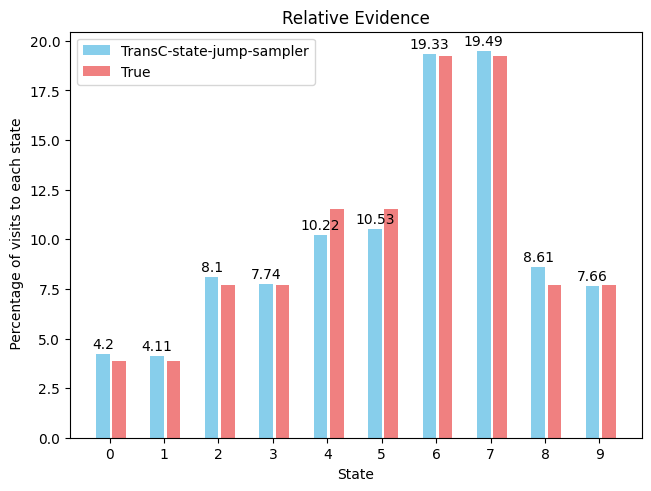

In [18]:
# Count visits to each state by Trans-D mcmc
if True:
    h = relative_marginal_likelihoods*100    
    # plot histogram of frequency of visits to each state

    labels = [str(i) for i in range(nstates)]
    x = np.arange(nstates)  # the label locations
    width = 0.25  # the width of the bars
    multiplier = 0

    fig, ax = plt.subplots(layout="constrained")
    offset = width * multiplier
    rects = ax.bar(x + offset, np.round(h, 2), width, label=alg, color="skyblue")
    ax.bar_label(rects, padding=2)
    multiplier += 1
    offset = width * multiplier + 0.05
    rects = ax.bar(
        x + offset, np.round(Evpc, 2), width, label="True", color="lightcoral"
    )
    #ax.bar_label(rects, padding=3)
    multiplier += 1
    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel(" Percentage of visits to each state")
    ax.set_xlabel("State")
    ax.set_title("Relative Evidence")
    ax.set_xticks(x + width / 2, labels)
    ax.legend(loc="upper left")
    # plt.savefig('SJ_relative_evidences.pdf')
    plt.show()

#### Convergence plot

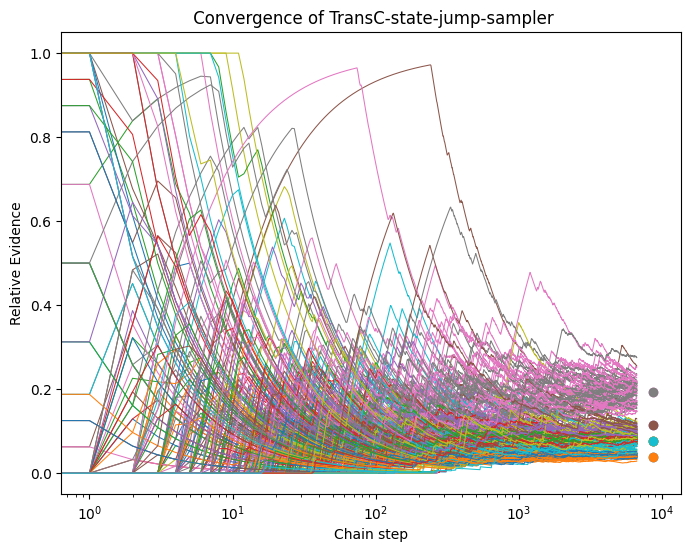

In [19]:
# plot relative number of visits to each state along the chain
if True:
    fig, axes = plt.subplots(figsize=(8, 6))
    if visits.ndim == 3:  # plot chains for each state and walker
        plt.semilogx(visits.reshape(np.shape(visits)[0], -1), lw=0.75)
    elif visits.ndim == 2:  # plot chains for each state average over walkers
        plt.semilogx(
            visits.reshape(np.shape(visits)[0], -1),
            lw=0.75,
            label=["State 1", "State 2", "State 3"],
        )
        plt.legend()
    plt.xlabel("Chain step")
    plt.ylabel("Relative Evidence")
    for i in range(nstates):
        plt.plot(len(visits) * 1.3, Ev[i], "o")
    plt.title(" Convergence of " + alg)
    plt.savefig('SJ_chains.pdf')
    plt.show()